# Section 2 : Exploratory Data Analysis

L'étape 2 de ce TP fil rouge à pour objectif de reprendre le corpus étudié et nettoyé disponible sur le notebook (TP_Jour1.ipynb) disponible sur mon github : 

Il consistera à : 
* Identifer les mots dominants et la répartition des classes
* Vectoriser le corpus avec TF-IDF de la librairie scikit-learn
* Construire des embeddings de phrase et calculer la similarité cosinus

> Les outils utilisés lors de ce projet sont tous Open-source !

### Chargement des librairies

In [1]:
import pandas as pd
import spacy
import re

## Recapitulatif du notebook TP_Jour1.ipynnb

### Chargement du modèle français de spacy

In [ ]:
nlp = spacy.load("fr_core_news_sm")

# Conservation de la négation dans les stop words
stop_words = nlp.Defaults.stop_words - {"ne", "pas", "non", "sans"}

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r" <.*?>", " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[!]{2 ,}", "!", text)
    text = re.sub(r"[.]{2 ,}", ".", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
# Chargement du corpus d'avis
df = pd.read_csv("corpus_avis.csv")

In [ ]:
# Nettoyage du texte
df["avis_clean"] = df["avis"].apply(clean_text)

# Suppression des doublons
df = df.drop_duplicates(subset="avis_clean").reset_index(drop=True)

# Tokenization et lemmatisation
df["tokens_final"] = df["avis_clean"].apply(
    lambda t: [tok.lemma_ for tok in nlp(t) if tok.is_alpha and tok.
               lemma_ not in stop_words])

print(df.shape)

(17, 4)


### Analyse Exploratoire : Structure du corpus

In [7]:
# Calcul de la longueur de chaque avis
df["longueur"] = df["avis_clean"].apply(lambda t: len(t.split()))

In [10]:
print("Métriques du corpus d'avis")
print(" -Nombre de documents :", len(df))
print(" -Longueur moyenne (mots) :", round(df["longueur"].mean(), 1))
print(" -Longueur mediane (mots) :", df["longueur"].median())
print(" -Longueur min / max :", df["longueur"].min(), "/", df["longueur"].max())

Métriques du corpus d'avis
 -Nombre de documents : 17
 -Longueur moyenne (mots) : 7.7
 -Longueur mediane (mots) : 8.0
 -Longueur min / max : 6 / 10


#### Explication des métriques
L'avis le plus court contient *6 mots* et l'avis le plus long en contient *10*. Sur un total de **17 avis**, **l'avis moyen** contient 7 mots et **l'avis médian** en contient 8.

In [15]:
print(" -Répartition des notes :")
print(df["note"].value_counts(sort=True).sort_index())

 -Répartition des notes :
note
1    4
2    2
3    3
4    2
5    6
Name: count, dtype: int64


#### Interpretation des avis
Les avis sont principalement concentré sur les extrémités avec 10 avis sur 17 concentré sur les deux extrémités dont 4 avis pour une note de 1 et 6 avis pour une note 5, laissant ainsi le milieu des notes avec une repartition plus faible.

### Analyse exploratoire : vocabulaire et fréquences

Matplotlib is building the font cache; this may take a moment.


Taille du vocabulaire : 62
Top 10 des mots les plus frequents :
[('apprendre', 2), ('tre', 2), ('ne', 2), ('ca', 2), ('qualite', 2), ('pas', 2), ('trop', 2), ('super', 1), ('plateform', 1), ('beaucoup', 1)]


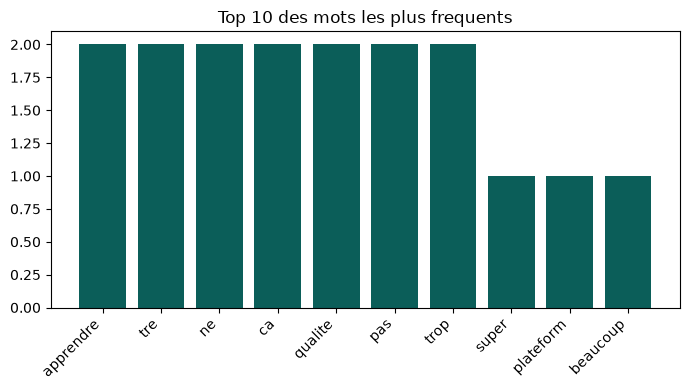

In [16]:
from collections import Counter
import matplotlib.pyplot as plt

tous_les_tokens = [tok for tokens in df["tokens_final"] for tok in tokens]
vocabulaire = set(tous_les_tokens)
frequences = Counter(tous_les_tokens)

print("Taille du vocabulaire :", len(vocabulaire))
print("Top 10 des mots les plus frequents :")
print(frequences.most_common(10))

top10 = frequences.most_common(10)
mots, comptes = zip(* top10)
plt.figure(figsize =(7, 4))
plt.bar(mots, comptes, color="#0B5E59")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 des mots les plus frequents")
plt.tight_layout()
plt.savefig("top_mots.png", dpi =120)
plt.show()

### Vectorisation TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(df["avis_clean"])

print("Dimensions de la matrice TF-IDF :", X_tfidf.shape)
print("Nombre de termes du vocabulaire TF-IDF :", len(vectorizer.get_feature_names_out()))

Dimensions de la matrice TF-IDF : (17, 98)
Nombre de termes du vocabulaire TF-IDF : 98


-> Explication à venir

In [24]:
# Récupération des noms de caractéristiques et des scores TF-IDF
features_names_scores = {
    "name": vectorizer.get_feature_names_out(),
    "score": X_tfidf[0].toarray()[0]
}

# Création d'un DataFrame pour les scores TF-IDF
df_features = pd.DataFrame(features_names_scores, columns=["name", "score"])

# Tri des caractéristiques par score TF-IDF décroissant
df_features_sorted = df_features.sort_values(by="score", ascending=False)
print(df_features_sorted.head())

          name     score
6       appris  0.447214
2           ai  0.447214
8     beaucoup  0.447214
65  plateforme  0.447214
86       super  0.447214


-> Explication à venir

### Embeddings de phrases avec Sentence-Transformers

In [25]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [26]:
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(df["avis_clean"].tolist())

print("Dimensions des embeddings :", embeddings.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\Rashops\Documents\Dev\Efrei\Efrei_M1\Natural Language Processing\TP_nlp_fil_rouge\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Rashops\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Dimensions des embeddings : (17, 384)


-> Explication à venir sur sentence transformers de hugging face

**Un embedding**: est la representation mathematique d'un objet complexe complexe sous forme de **vecteur numérique** dans l'optique de le rendre comprehensible par l'intelligence artificielle.

Dans notre cas un embedding est un avis representé sous forme d'un vecteur de 384 dimensions.

In [31]:
# TODO : choisissez deux avis que vous jugez proches en sens (par ex.
# deux avis positifs)
i, j = 8, 5 # <-- remplacez par les indices de votre choix
sim = cosine_similarity ([embeddings[i]], [embeddings[j]])[0][0]
print(df["avis_clean"][i])
print(df["avis_clean"][j])
print("Similarite cosinus :", round(sim , 3))

excellent rapport qualite -prix , a essayer.
je recommande vivement , contenu de qualite :)
Similarite cosinus : 0.672


-> Explication à venir sur l'embedding et sur la similarité cosinus

### TF-IDF vs embeddings : recherche sémantique

In [ ]:
requete = "je suis tres content du service propose"

# Encodage de la requete dans les deux espaces
requete_tfidf = vectorizer.transform([requete])
requete_embed = model.encode([requete])

# Similarite avec chaque avis du corpus
sim_tfidf = cosine_similarity(requete_tfidf, X_tfidf)[0]
sim_embed = cosine_similarity(requete_embed, embeddings)[0]

meilleur_tfidf = sim_tfidf.argmax()
meilleur_embed = sim_embed.argmax()

print("Meilleur resultat (TF-IDF) :", df["avis_clean"][meilleur_tfidf],
      "| score :", round(sim_tfidf[meilleur_tfidf], 3))
print("Meilleur resultat (embeddings) :", df["avis_clean"][meilleur_embed], 
      "| score :", round(sim_embed[meilleur_embed], 3))

Meilleur resultat (TF-IDF) : je ne suis pas satisfait du tout , remboursez -moi. | score : 0.44
Meilleur resultat (embeddings) : parfait ! exactement ce qu’il me fallait merci | score : 0.627


Explication sur la différence entre TF-IDF et un modèle Transformers

**L'algorithme de TF-IDF** cherche à identifier les mots en commun sans réellement comprendre la totalité de la phrase. Ce qui nous donne souvent un resultat avec un score élevé sans que les phrases aient un sens similaires (comme dans notre exemple précédent).

Alors que **les Transformers** sont basé sur le mechanisme de l'attention et cherchent plus à comprendre le sens de la phrase en regardant l'agencement des mots les un avec les autres.

### Vétification des resultats

In [33]:
print(f"X_tfidf_shape : {X_tfidf.shape[0]}")
print(f"embeddings_shape : {embeddings.shape[0]}")
print(f"df_shape : {df.shape[0]}")

X_tfidf_shape : 17
embeddings_shape : 17
df_shape : 17


In [34]:
print(f"embeddings_sum : {embeddings.sum(axis=1)}")

embeddings_sum : [ 0.1336647   0.3683678  -0.05393815 -0.1867001   0.03369796 -0.44358617
 -0.06908965 -0.02238417 -0.00963736 -0.4523933   0.4077381   0.08849072
  0.01373911 -0.03294575  0.13885629  0.30810285  0.1303041 ]


Comme indiqué sur les resultats ci-dessus le nombre d'avis est resté le même pour toutes les méthodes utilisées. 

Les vecteurs TF-IDF ont normalement la même taille pour tous les documents utilisés lors de cet exercice.

Vecteur d'embedding null ou incohérent ??

Pour retrouver des avis similaires à un requete libre, la méthode la plus efficace serait l'embedding avec les transformers car basé sur le méchanisme de l'attention ils sont capables de comprendre le sens d'une phrase.

Pour faire le classement d'avis par note la méthode plus efficace serait le TF-IDF car il attribut un score à chaque mot selon le but recherché, donc ce que permet d'établir un classement.

# Documentation finale

* Indicateurs EDA : La longueur moyenne est de 7 mots et la taille du vocabulaire est de 62 mots
* Répartition des classes : Les avis sont fortement concentré sur les extrémités des notes (1 & 5)
* Les 5 mots dominants dans le TF-IDF sont : appris, ai beaucoup, plateforme, super
* Representation retenu : Lire l'explication précédente
* Observation TF-IDF vs Embedding : Pour un classement sur base d'un score la méthode TF-IDF se révèle plus efficace mais pour rapprocher deux notions qui sont différentes aux premiers regard l'Embedding est supérieur.
* Limites observées : Pauvreté du jeux de données, aucun fine-tuning effectué

### Bonus
Tester l'Embedding avec un modèle Ollama
Tester le Word2Vec, N-Gram et Bag of Words

#### Suite 
* Affichez les 5 avis les plus proches (embeddings) d’un avis négatif de votre choix.
* Testez un autre modèle Sentence-Transformers et comparez les scores de similarité obtenus.
* Réduisez les embeddings en 2 dimensions (ex. PCA de scikit-learn) et visualisez le nuage de points : les avis positifs et négatifs se séparent-ils visuellement ?